# Imports

In [1]:
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import uuid
import time

import random
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

from PIL import Image
import matplotlib.image as mpimg

import torch
import torchvision.transforms as T
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# !pip install tensorflow
import tensorflow as tf
import keras

from google.colab import drive

In [2]:
drive.mount('/content/drive')

# Caminho base atualizado
base_path = "/content/drive/MyDrive/MDSAA-DS/DL-project/dataverse_files" #maria
#base_path = "/content/drive/MyDrive/Projects_MDSAA/DL-project/dataverse_files" #bruna

image_dirs = [
    "HAM10000_images_part_1",
    "HAM10000_images_part_2",
    "ISIC2018_Task3_Test_Images"
]

image_paths = []

# path for the new images
aug_dir = os.path.join(base_path, "HAM10000_augmented")
if not os.path.exists(aug_dir):
    os.makedirs(aug_dir)

Mounted at /content/drive


In [3]:
# IMPORT DATASET
for folder in image_dirs:
    folder_path = os.path.join(base_path, folder)
    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append({
                "image_id": os.path.splitext(file)[0],
                "image_path": os.path.join(folder_path, file)
            })

images_df = pd.DataFrame(image_paths)
metadata_path = os.path.join(base_path, "HAM10000_metadata")
metadata_df = pd.read_csv(metadata_path, sep=",")
merged_df = pd.merge(images_df, metadata_df, on="image_id", how="left")
merged_df.head()

,image_id,image_path,lesion_id,dx,dx_type,age,sex,localization,dataset
0,ISIC_0028323,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0001900,bcc,histo,80.0,female,chest,vidir_modern
1,ISIC_0028299,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0001540,nv,follow_up,60.0,male,lower extremity,vidir_molemax
2,ISIC_0028318,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0001886,nv,follow_up,50.0,female,lower extremity,vidir_molemax
3,ISIC_0028296,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0006365,nv,follow_up,80.0,male,lower extremity,vidir_molemax
4,ISIC_0028309,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0006770,bkl,consensus,70.0,female,back,vidir_modern


In [4]:
merged_df = merged_df.dropna()  # apenas pq n foi preprocessed

# Augmentation Strategies per Class

Goal: don't make all classes equal — reduce the imbalance without oversampling minority classes too aggressively.
A common target is a soft balance — bring minority classes up to a reasonable floor without cloning the same image hundreds of times (which causes overfitting):

Using ImageNet normalization is essential because pretrained models were optimized on data normalized with these exact statistics. Applying different normalization introduces a domain shift that prevents the learned features from activating as intended, degrading transfer learning performance. Matching the training distribution ensures the pretrained weights function optimally on your new task.

In [5]:
# IMAGE NET TRANSFER LEARNING WEIGHTS
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

In [6]:
# ── STRATEGY 1 — Light (geometric only) ──────────────────────────────────────
# Safe flips and rotation, nothing that touches color or structure
strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Save version without ToTensor and Normalize
save_strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
])

# ── STRATEGY 2 — Moderate (geometry + mild color) ─────────────────────────────
# Adds subtle brightness/contrast to simulate lighting variation
strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.05)),  # simulates hair/occlusion
])

# Save version without ToTensor and Normalize
save_strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

# ── STRATEGY 3 — Aggressive (everything + elastic + perspective) ────────────
# Most aggressive — use only for extreme minority classes (vasc, df)
strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.08)),
])

# Save version without ToTensor and Normalize
save_strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
])

# Base strategy, for the majority class
strat_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

save_strat_base = transforms.Compose([]) #no transformations for base when saving

In [7]:
strategy_map = {
    "nv":    strat_base,
    "mel":   strategy_1,
    "bkl":   strategy_1,
    "bcc":   strategy_2,
    "akiec": strategy_2,
    "vasc":  strategy_3,
    "df":    strategy_3,
}

save_strategy_map = {
    "nv":    save_strat_base,
    "mel":   save_strategy_1,
    "bkl":   save_strategy_1,
    "bcc":   save_strategy_2,
    "akiec": save_strategy_2,
    "vasc":  save_strategy_3,
    "df":    save_strategy_3,
}

augmentation_multiplier_map = {
    "nv":    1,
    "mel":   3,
    "bkl":   3,
    "bcc":   4,
    "akiec": 5,
    "vasc":  8,
    "df":    8,
}

# alterar consoante código de resize do Graça
resize = transforms.Resize((224, 224))

# Offline Augmentation

In [8]:
def apply_augmentation(image_path, label):
    with Image.open(image_path) as img:
        img = resize(img.convert("RGB"))
        return strategy_map[label](img)

In [9]:
def offline_augmentation(df, label, multiplier):
    new_rows = []
    class_df = df[df['dx'] == label]
    paths = class_df['image_path'].tolist()

    n_to_generate = len(paths) * (multiplier - 1)

    for i in range(int(n_to_generate)):
        original_path = paths[i % len(paths)]
        original_row = class_df.iloc[i % len(class_df)] # Get the full row for metadata

        img = Image.open(original_path).convert('RGB')
        img = resize(img) # Apply resize

        transform = save_strategy_map.get(label) # Use save_strategy_map
        if transform:
            img = transform(img)

        new_id = f"AUG_{label}_{uuid.uuid4().hex[:8]}"
        new_filename = f"{new_id}.jpg"
        save_path = os.path.join(aug_dir, new_filename)
        img.save(save_path, "JPEG", quality=95)

        new_row_dict = {
            'image_id': new_id,
            'image_path': save_path,
            'dx': label,
            'dataset': 'augmented' # Mark as augmented
        }
        # Copy other metadata from the original row, but generate new lesion_id
        for col in ['dx_type', 'age', 'sex', 'localization']:
            if col in original_row:
                new_row_dict[col] = original_row[col]
        new_row_dict['lesion_id'] = f"AUG_LESION_{label}_{uuid.uuid4().hex[:8]}" # Always generate new lesion_id

        new_rows.append(new_row_dict)
    return new_rows

In [10]:
# Function to denormalize the images, only for visualization purposes
def denormalize(tensor, mean, std):
    # Reverse: x = (z * std) + mean
    img = tensor.cpu().numpy().transpose((1, 2, 0))
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

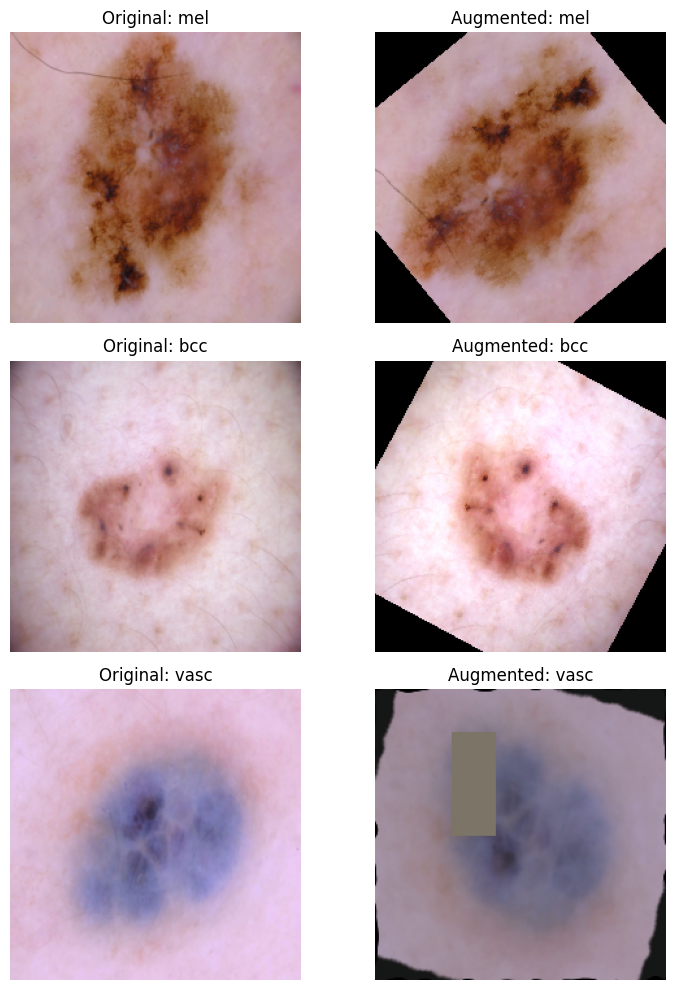

In [11]:
test_labels = ['mel', 'bcc', 'vasc']
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for i, label in enumerate(test_labels):
    sample_path = merged_df[merged_df['dx'] == label].sample(1).iloc[0]['image_path']

    # open once
    with Image.open(sample_path) as img:
        img = img.convert("RGB")
        original = resize(img)
        aug_tensor = strategy_map[label](original)

    aug_final = denormalize(aug_tensor, mean, std)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original: {label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(aug_final)
    axes[i, 1].set_title(f"Augmented: {label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# 6 MIN
# generate augmented images and collect metadata
all_new_metadata = []
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor: # Use all available CPU cores
    futures = []
    for label, multiplier in augmentation_multiplier_map.items():
        if multiplier > 1:
            print(f"Submitting task for augmenting {label} (multiplier: {multiplier})")
            # pass the original merged_df to the function
            futures.append(executor.submit(offline_augmentation, merged_df, label, multiplier))

    for future in tqdm(futures, desc="Generating all augmented images"): # Use tqdm on futures list
        all_new_metadata.extend(future.result())

augmented_df = pd.DataFrame(all_new_metadata)

# handle undersampling of 'nv' from the original merged_df
nv_original_df = merged_df[merged_df["dx"] == "nv"]
nv_undersampled_df = nv_original_df.sample(n=4500, random_state=42)

# exclude original 'nv' from merged_df and add the undersampled version
non_nv_original_df = merged_df[merged_df["dx"] != "nv"]
processed_original_df = pd.concat([non_nv_original_df, nv_undersampled_df], ignore_index=True)

# combine processed original with augmented
final_df = pd.concat([processed_original_df, augmented_df], ignore_index=True)

# save  new CSV
final_df.to_csv(os.path.join(base_path, "augmented_metadata.csv"), index=False)

print("\nFinal distribution after offline augmentation and undersampling:")
print(final_df["dx"].value_counts())

Submitting task for augmenting mel (multiplier: 3)
Submitting task for augmenting bkl (multiplier: 3)
Submitting task for augmenting bcc (multiplier: 4)
Submitting task for augmenting akiec (multiplier: 5)
Submitting task for augmenting vasc (multiplier: 8)
Submitting task for augmenting df (multiplier: 8)


Generating all augmented images: 100%|██████████| 6/6 [06:39<00:00, 66.54s/it] 



Final distribution after offline augmentation and undersampling:
dx
nv       4500
mel      3333
bkl      3267
bcc      2056
akiec    1635
vasc     1136
df        920
Name: count, dtype: int64


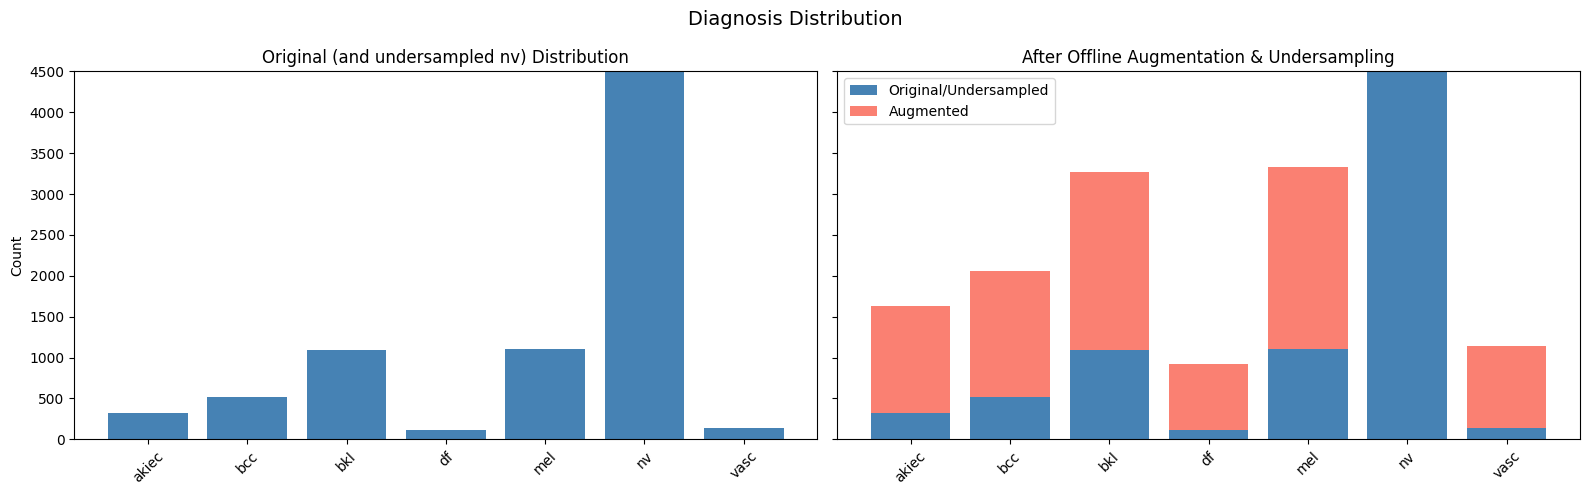

In [13]:
labels = sorted(final_df["dx"].unique())

original_distribution_counts = [len(processed_original_df[processed_original_df["dx"] == l]) for l in labels]
augmented_counts_from_df = [len(augmented_df[augmented_df["dx"] == l]) for l in labels]

x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# ── Original
axes[0].bar(x, original_distribution_counts, color="steelblue")
axes[0].set_title("Original (and undersampled nv) Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")

# ── After undersampled nv + augmented others stacked
axes[1].bar(x, original_distribution_counts, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_counts_from_df, bottom=original_distribution_counts, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()

plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Old code

In [ ]:
"""
# 1 minute
augmented_images = {
                      label : augment_class(label, multiplier)
                          for label, multiplier in augmentation_multiplier_map.items()
                            if multiplier > 1
                      }

In [ ]:
"""
def augment_class(label, multiplier_factor):
    paths = merged_df.loc[merged_df["dx"] == label, "image_path"].tolist()
    target_size = len(paths) * (multiplier_factor - 1)

    # cycle paths to match target size
    cycled_paths = [paths[i % len(paths)] for i in range(target_size)]

    with ThreadPoolExecutor(max_workers=16) as executor:
        results = list(tqdm(
            executor.map(lambda p: apply_augmentation(p, label), cycled_paths),
            total=target_size,
            desc=f"Augmenting {label}"
        ))

    return results

In [ ]:
"""
def load_image(path):
    with Image.open(path) as img:
        return strat_base(img.convert("RGB"))  # returns normalized tensor

with ThreadPoolExecutor(max_workers=16) as executor:
    tensors = list(tqdm(executor.map(load_image, merged_df["image_path"]), total=len(merged_df)))

In [ ]:
"""
original_images = {
    label : [tensors[i] for i in merged_df.index[merged_df["dx"] == label].tolist()]
    for label in merged_df["dx"].unique()
  }

In [ ]:
"""
all_images = {
    label: original_images[label] + augmented_images.get(label, [])
    for label in original_images
}

del all_images[np.nan] # remover o nan, preprocessing resolve isto quando juntarmos

# quick sanity check
for label, imgs in all_images.items():
    print(f"{label}: {len(imgs)}")

In [ ]:
# ja e feito na funcao anterior
"""
nv_undersampled = (merged_df[merged_df["dx"] == "nv"]
                   .sample(n=4500, random_state=42)
                   .index.tolist())

original_images["nv"] = [original_images["nv"][i] for i in range(len(original_images["nv"]))
                  if merged_df.index[merged_df["dx"] == "nv"].tolist()[i] in nv_undersampled]

# Online Augmentation

The main issue with offline augmentation here is that the augmented images are fixed — the model sees the same synthetic versions every epoch, which is particularly problematic for vasc and df where we're already working with very few original images.

Online augmentation solves this by applying random transformations fresh each epoch, giving the model genuinely different views of each image over time. Combined with WeightedRandomSampler to control class frequency per batch and class-weighted loss, this approach handles the imbalance more elegantly without any RAM overhead.

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

In [15]:
class HAMDataset(Dataset):
    def __init__(self, df, transform_map):
        self.df = df
        self.transform_map = transform_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            img = resize(img.convert("RGB"))
        return self.transform_map[row["dx"]](img), row["label_idx"]

# Comparison: Offline vs Online

## Setting up

In [13]:
"""
print("ORIGINAL DATASET CLASS DISTRIBUTION (TO BE ONLINE AUGMENTED)")
print( merged_df.dx.value_counts(normalize=True)*100 )
print("\n")
print("OFFLINE AUGMENTED DATASET CLASS DISTRIBUTION")
print( final_df.dx.value_counts(normalize=True)*100 )
"""

ORIGINAL DATASET CLASS DISTRIBUTION (TO BE ONLINE AUGMENTED)
dx
nv       66.880900
mel      11.156859
bkl      10.935931
bcc       5.161679
akiec     3.283792
vasc      1.425989
df        1.154850
Name: proportion, dtype: float64


OFFLINE AUGMENTED DATASET CLASS DISTRIBUTION
dx
nv       26.710987
mel      19.783938
bkl      19.392177
bcc      12.203953
akiec     9.704992
vasc      6.743040
df        5.460913
Name: proportion, dtype: float64


In [35]:
# Label encoding - secalhar incluir no preprocessing
label2idx = {label: i for i, label in enumerate(sorted(final_df["dx"].unique()))}
idx2label = {i: label for label, i in label2idx.items()}

merged_df["label_idx"] = merged_df["dx"].map(label2idx)

In [36]:
# Split
lesion_ids = merged_df["lesion_id"].unique()
train_ids, temp_ids = train_test_split(lesion_ids, test_size=0.2, random_state=42)
val_ids, test_ids   = train_test_split(temp_ids,   test_size=0.5, random_state=42)

train_split = merged_df[merged_df["lesion_id"].isin(train_ids)].reset_index(drop=True)
val_split   = merged_df[merged_df["lesion_id"].isin(val_ids)].reset_index(drop=True)
test_split  = merged_df[merged_df["lesion_id"].isin(test_ids)].reset_index(drop=True)

print(f"ONLINE: Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_split)}")

ONLINE: Train: 7970 | Val: 988 | Test: 1000


In [37]:
# Class weights
classes = np.array(sorted(train_split["dx"].unique()))

class_weights = compute_class_weight(class_weight="balanced",classes=classes,y=train_split["dx"])

class_weights_dict = {i: w for i, w in enumerate(class_weights)}
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

In [38]:
# Seeding
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
tf.random.set_seed(seed)

In [39]:
epochs = 5
max_steps = 100

## Offline training

### Final setup

In [28]:
IMG_SIZE = (224, 224)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [40]:
def make_dataset(df, shuffle=False):
    paths = df["image_path"].values
    labels = df["label_idx"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y), num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))

    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_split, shuffle=True)
val_ds   = make_dataset(val_split)
test_ds  = make_dataset(test_split)

In [32]:
model_off = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu", input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(len(label2idx))
])

model_off.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Model training

In [34]:
class BatchTimeCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.batch_times = []

    def on_train_batch_begin(self, batch, logs=None):
        self.batch_start = time.time()

    def on_train_batch_end(self, batch, logs=None):
        elapsed = time.time() - self.batch_start
        self.batch_times.append(elapsed)

batch_time_cb = BatchTimeCallback()

model_off.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=max_steps,
    class_weight=class_weights_dict,
    callbacks=[batch_time_cb]
)

print(f"Avg batch time: {sum(batch_time_cb.batch_times)/len(batch_time_cb.batch_times):.4f} sec")

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 424ms/step - accuracy: 0.1084 - loss: 1.9201 - val_accuracy: 0.3137 - val_loss: 1.9341
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.2697 - loss: 1.8998 - val_accuracy: 0.1956 - val_loss: 1.9325
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.2815 - loss: 1.9497

KeyboardInterrupt: 

- 6 min to generate augmented images (TPU, Colab)
-

## Online training

### Final setup

In [ ]:
# ── DATASETS ──────────────────────────────────────────────────────────────────
train_dataset = HAMDataset(train_split, strategy_map)
val_dataset   = HAMDataset(val_split,   {label: strat_base for label in label2idx})
test_dataset  = HAMDataset(test_split,  {label: strat_base for label in label2idx})

In [ ]:
# ── SAMPLER ───────────────────────────────────────────────────────────────────
sample_weights = train_split["dx"].map(dict(zip(classes, class_weights))).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [ ]:
# ── DATALOADERS ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,     num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,        num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,        num_workers=4, pin_memory=True)

In [ ]:
# ── MODEL ─────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_on = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=6),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(8, len(label2idx))
).to(device)

In [ ]:
# ── LOSS / OPTIMIZER ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model_on.parameters(), lr=1e-3)

### Model training

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer,
          scheduler=None, epochs=10, save_path="best_model.pth",
          max_steps=None):  # <-- NEW (for fair comparison)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "epoch_time": [], "throughput": []
    }

    best_val_loss = float("inf")

    for epoch in range(epochs):

        # ── TRAIN ─────────────────────────────────────────────────────────────
        model.train()
        train_loss, train_correct = 0, 0

        batch_times = []

        start_epoch = time.time()
        end_data = time.time()

        for step, (images, labels) in enumerate(
            tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        ):
            if max_steps and step >= max_steps:
                break

            # ── DATA TIME ──
            batch_start_total = time.time()

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # sync GPU for correct timing
            if device.type == "cuda":
                torch.cuda.synchronize()

            batch_end_total = time.time()

            total_batch_time = batch_end_total - batch_start_total
            batch_times.append(total_batch_time)

            # ── METRICS ──
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        end_epoch = time.time()

        # ── VALIDATE ──────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()


        # ── METRICS ───────────────────────────────────────────────────────────
        num_train_batches = step + 1
        train_loss = train_loss / num_train_batches
        val_loss   = val_loss   / len(val_loader)

        train_acc = train_correct / (num_train_batches * train_loader.batch_size)
        val_acc    = val_correct   / len(val_loader.dataset)

        epoch_time = end_epoch - start_epoch
        avg_batch_time = sum(batch_times) / len(batch_times)

        samples_processed = num_train_batches * train_loader.batch_size
        throughput = samples_processed / epoch_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)
        history["throughput"].append(throughput)

        if scheduler:
            scheduler.step()

        print(f"\nEpoch {epoch+1:02d}/{epochs}")
        print(f"{num_train_batches}/{num_train_batches} - "
              f"Epoch time: {epoch_time:.0f}s - "
              f"Avg batch time: {avg_batch_time:.4f}s/step - "
              f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - "
              f"val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

        # ── SAVE BEST ─────────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"✔ Best model saved (val_loss: {val_loss:.4f})")

    return history

In [ ]:
T_max = epochs * max_steps
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)

history = train(
    model       = model_on,
    train_loader= train_loader,
    val_loader  = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    scheduler   = scheduler,
    epochs      = epochs,
    max_steps   = max_steps,
    save_path   = "drive/MyDrive/MDSAA-DS/test-model.pth"
)

Epoch 1/5 [Val]: 100%|██████████| 31/31 [00:06<00:00,  4.71it/s]



Epoch 01/5
101/101 - Epoch time: 41s - Avg batch time: 0.1855s/step - accuracy: 0.2014 - loss: 1.7179 - val_accuracy: 0.3219 - val_loss: 2.0182
✔ Best model saved (val_loss: 2.0182)


Epoch 2/5 [Val]: 100%|██████████| 31/31 [00:06<00:00,  4.63it/s]



Epoch 02/5
101/101 - Epoch time: 42s - Avg batch time: 0.1976s/step - accuracy: 0.2166 - loss: 1.6793 - val_accuracy: 0.3563 - val_loss: 1.9198
✔ Best model saved (val_loss: 1.9198)


Epoch 3/5 [Val]: 100%|██████████| 31/31 [00:06<00:00,  4.68it/s]



Epoch 03/5
101/101 - Epoch time: 41s - Avg batch time: 0.1962s/step - accuracy: 0.2153 - loss: 1.6858 - val_accuracy: 0.3401 - val_loss: 1.9433


Epoch 4/5 [Val]: 100%|██████████| 31/31 [00:06<00:00,  4.69it/s]



Epoch 04/5
101/101 - Epoch time: 45s - Avg batch time: 0.2130s/step - accuracy: 0.2386 - loss: 1.6515 - val_accuracy: 0.3532 - val_loss: 1.9035
✔ Best model saved (val_loss: 1.9035)


Epoch 5/5 [Val]: 100%|██████████| 31/31 [00:06<00:00,  4.80it/s]


Epoch 05/5
101/101 - Epoch time: 42s - Avg batch time: 0.1972s/step - accuracy: 0.2237 - loss: 1.6466 - val_accuracy: 0.3603 - val_loss: 1.8874
✔ Best model saved (val_loss: 1.8874)


### Plot

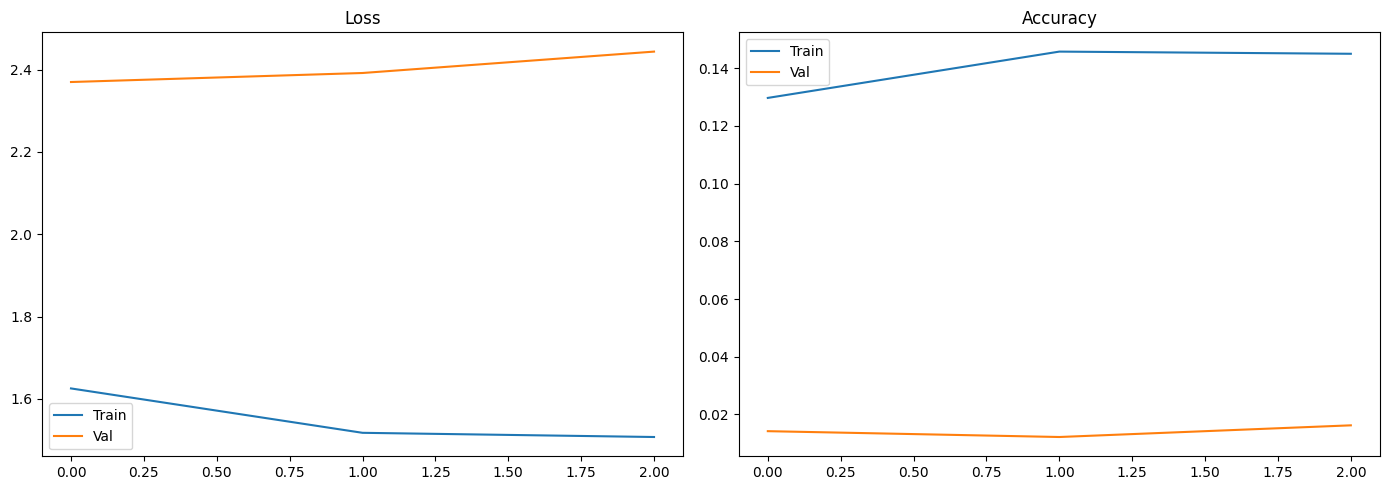

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final comparison
- Avg batch time (time per step):
  - Offline: ~0.4 sec
  - Online: ~0.2 sec

- Epoch time:
  - Offline: ~20 sec
  - Online: ~42 sec

👉 PyTorch is ~1.8–2× faster per batch


Now your comparison is actually valid, and it shows:

🔵 PyTorch advantage
faster iteration speed
lower per-step overhead
better pipeline efficiency


🟢 Keras behavior
slower per-step execution
but stable scaling with steps
likely tf.data + augmentation overhead